=== TEST SET PERFORMANCE ===
Accuracy: 1.0000 (100.00%)


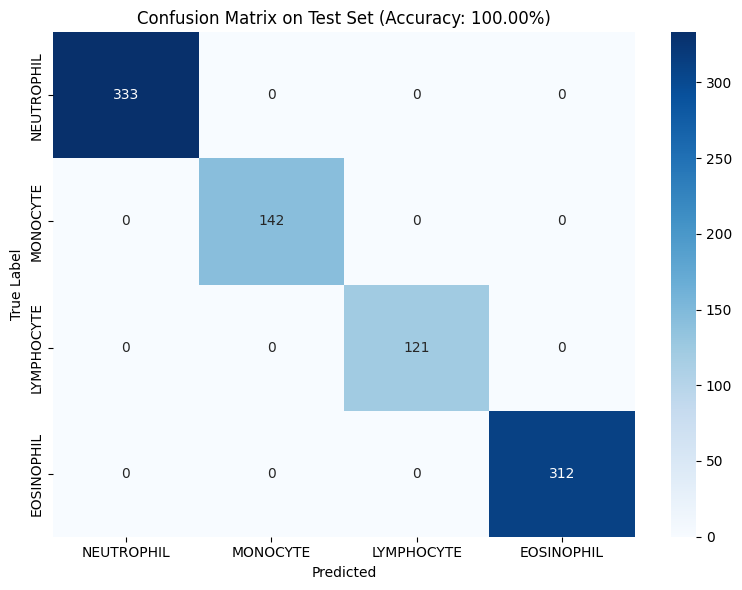


=== PER-CLASS PERFORMANCE ===
NEUTROPHIL: Precision=1.000, Recall=1.000, F1=1.000
MONOCYTE: Precision=1.000, Recall=1.000, F1=1.000
LYMPHOCYTE: Precision=1.000, Recall=1.000, F1=1.000
EOSINOPHIL: Precision=1.000, Recall=1.000, F1=1.000


In [ ]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path("..")
RESULTS_JSON = PROJECT_ROOT / "outputs" / "reports" / "classification_test_results.json"

if not RESULTS_JSON.exists():
    print("[WARNING] Results file not found. Run 08_evaluate_classification.py first.")
else:
    with open(RESULTS_JSON, 'r') as f:
        results = json.load(f)
    
    
    accuracy = results['test_accuracy']
    print(f"=== TEST SET PERFORMANCE ===")
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    
    conf_matrix = np.array(results['confusion_matrix'])
    class_names = ['NEUTROPHIL', 'MONOCYTE', 'LYMPHOCYTE', 'EOSINOPHIL']
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix on Test Set (Accuracy: {accuracy*100:.2f}%)')
    plt.xlabel('Predicted')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
    
    
    print("\n=== PER-CLASS PERFORMANCE ===")
    for class_name in class_names:
        metrics = results['classification_report'][class_name]
        print(f"{class_name}: Precision={metrics['precision']:.3f}, Recall={metrics['recall']:.3f}, F1={metrics['f1-score']:.3f}")

[INFO] Loaded 30 epochs of training data.
   train_loss  val_loss  train_acc   val_acc
0    0.151369  0.145757   0.955253  0.969163
1    0.058448  0.098944   0.986094  0.975771
2    0.038924  0.006079   0.990637  0.997797
3    0.024433  0.856851   0.995181  0.756608
4    0.030794  0.052352   0.993116  0.983480


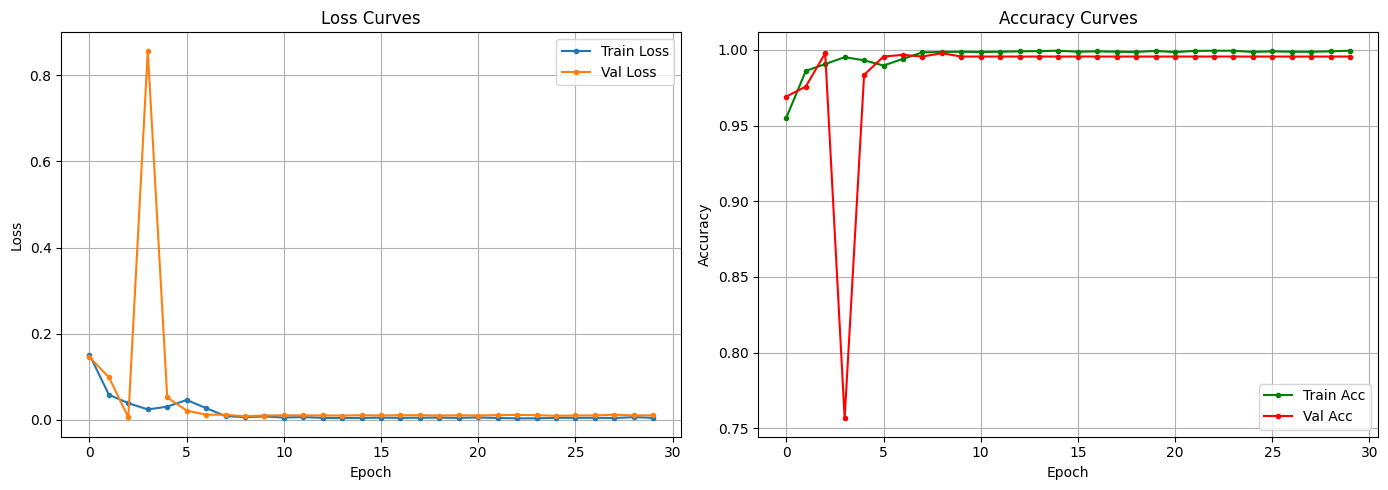


=== BEST MODEL SUMMARY ===
Best Epoch: 3
Best Validation Accuracy: 0.9978
Corresponding Validation Loss: 0.0061

=== OVERFITTING CHECK ===
Final Train Acc: 0.9994
Final Val Acc: 0.9956
Gap (Train - Val): 0.0039
[SUCCESS] Model is generalizing well.


In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import numpy as np

PROJECT_ROOT = Path("..")
HISTORY_CSV = PROJECT_ROOT / "outputs" / "logs" / "classification_history.csv"

if not HISTORY_CSV.exists():
    print(f"[WARNING] History file not found at {HISTORY_CSV}. Run training first.")
else:
    
    df = pd.read_csv(HISTORY_CSV)
    print(f"[INFO] Loaded {len(df)} epochs of training data.")
    print(df.head())

    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    
    axes[0].plot(df.index, df['train_loss'], label='Train Loss', marker='o', markersize=3)
    axes[0].plot(df.index, df['val_loss'], label='Val Loss', marker='o', markersize=3)
    axes[0].set_title('Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    
    axes[1].plot(df.index, df['train_acc'], label='Train Acc', marker='o', markersize=3, color='green')
    axes[1].plot(df.index, df['val_acc'], label='Val Acc', marker='o', markersize=3, color='red')
    axes[1].set_title('Accuracy Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    
    best_epoch = df['val_acc'].idxmax()
    print(f"\n=== BEST MODEL SUMMARY ===")
    print(f"Best Epoch: {best_epoch + 1}")
    print(f"Best Validation Accuracy: {df.loc[best_epoch, 'val_acc']:.4f}")
    print(f"Corresponding Validation Loss: {df.loc[best_epoch, 'val_loss']:.4f}")
    
    
    final_train_acc = df['train_acc'].iloc[-1]
    final_val_acc = df['val_acc'].iloc[-1]
    gap = final_train_acc - final_val_acc
    
    print(f"\n=== OVERFITTING CHECK ===")
    print(f"Final Train Acc: {final_train_acc:.4f}")
    print(f"Final Val Acc: {final_val_acc:.4f}")
    print(f"Gap (Train - Val): {gap:.4f}")
    if gap > 0.1:
        print("[WARNING] The model may be overfitting! Consider using more augmentation or reducing model complexity.")
    else:
        print("[SUCCESS] Model is generalizing well.")